# 3.Clasificación de Aditivos mediante Machine Learning No Supervisado

Este cuaderno detalla el proceso de análisis multivariante y segmentación de una base de datos de aditivos alimentarios enriquecida con evidencia científica de PubMed.

### 1. Configuración del Entorno
Se importan las herramientas esenciales para el flujo de trabajo de Ciencia de Datos:
* **Procesamiento**: `pandas` para la gestión de dataframes y `numpy` para operaciones numéricas.
* **Visualización**: `matplotlib.plt` y `seaborn` para la creación de gráficos estadísticos y `matplotlib.cm` para el mapeo de colores en clusters.
* **Modelado (Scikit-Learn)**:
    * `StandardScaler`: Normalización de métricas científicas (cargas de toxicidad).
    * `KMeans`: Algoritmo de agrupamiento no supervisado.
    * `PCA`: Reducción de dimensiones para inspección visual.
    * `silhouette_score`: Métrica de validación de la calidad del agrupamiento.


In [ ]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# Machine Learning (Scikit-Learn)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

### 2. Ingeniería de Características y Preprocesamiento
Antes del entrenamiento, los datos pasan por una fase de refinamiento:
* **Selección de Variables**: Se utilizan las dimensiones de riesgo obtenidas de PubMed (como toxicidad genética, carcinogenicidad, etc.) y se excluyen los identificadores no numéricos como `id_original`.
* **Escalado Logarítmico**: Se aplica `np.log1p` para manejar el sesgo de los conteos de PubMed, donde unos pocos aditivos tienen miles de citas y muchos otros muy pocas.
* **Estandarización**: Se centra la media en 0 y la varianza en 1 para que ninguna dimensión científica domine injustamente el modelo.

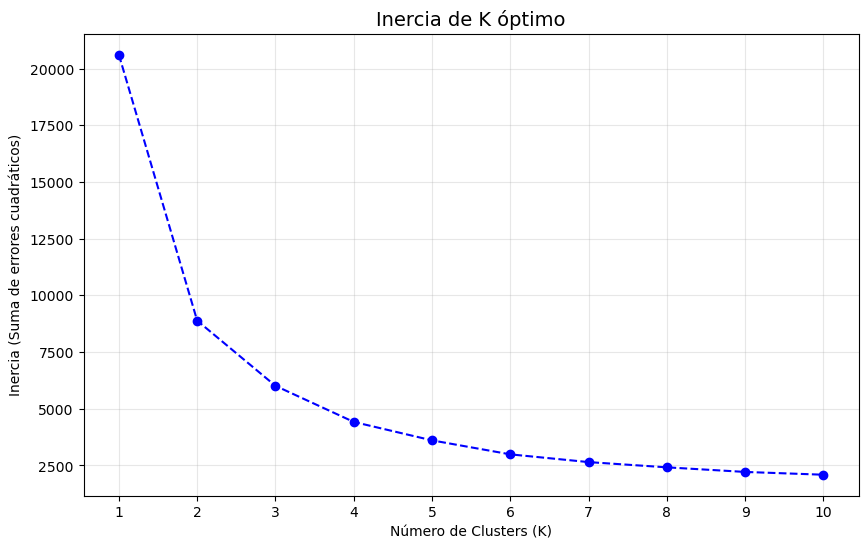

Inercia para K=2: 8887.25
Inercia para K=3: 6012.34
Inercia para K=4: 4420.92
Inercia para K=5: 3607.98


In [ ]:
# 1. Cargar el dataset de aditivos
df_pubmed = pd.read_csv('../data/dataset_final_con_codigos.csv')


# Seleccionar columnas numéricas para el clustering
features = df_pubmed.columns.drop(['id_original', 'nombre_referencia', 'codigo_e', 'id'])
X = df_pubmed[features]

# Preprocesamiento: Log-scaling + StandardScaler
X_log = np.log1p(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# Calcular la inercia para el Método del Codo (Elbow Method)
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Visualización del Método del Codo
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='--', color='b')
plt.title('Inercia de K óptimo', fontsize=14)
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia (Suma de errores cuadráticos)')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.savefig('../outputs/plots/aditives/metodo_codo.png')
plt.show()

print(f"Inercia para K=2: {inertia[1]:.2f}")
print(f"Inercia para K=3: {inertia[2]:.2f}")
print(f"Inercia para K=4: {inertia[3]:.2f}")
print(f"Inercia para K=5: {inertia[4]:.2f}")

Para n_clusters = 2, el promedio de silhouette es: 0.5510


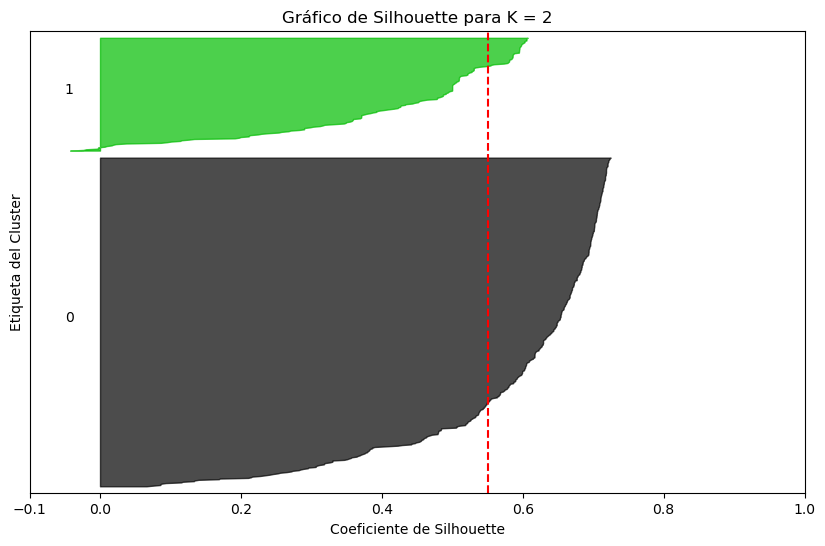

Para n_clusters = 3, el promedio de silhouette es: 0.3956


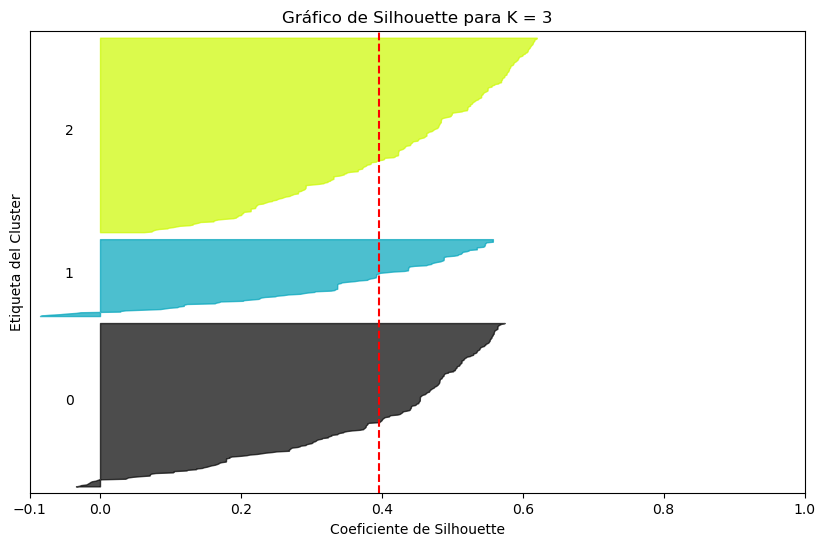

Para n_clusters = 4, el promedio de silhouette es: 0.4059


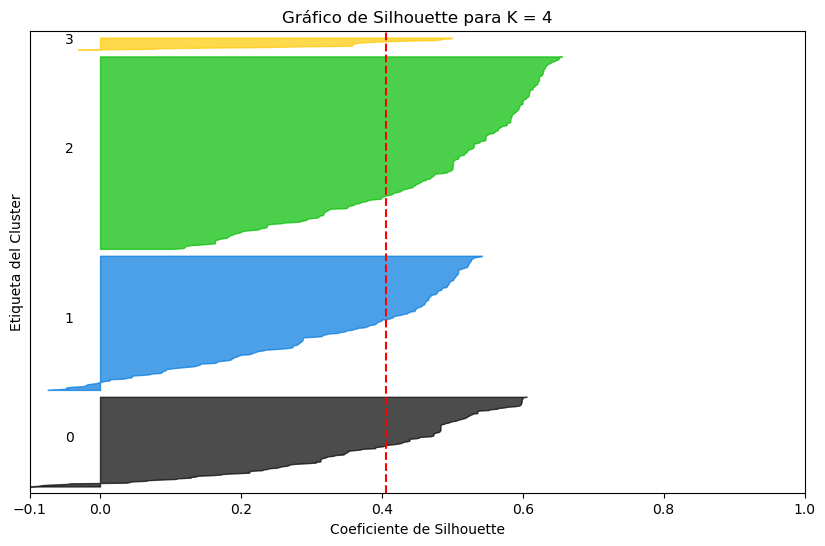

In [ ]:
# Preparación de datos (Log + Scaler)
X_log = np.log1p(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# Vamos a evaluar Silhouette para K=3 y K=4 que eran nuestros candidatos
range_n_clusters = [2, 3, 4]

for n_clusters in range_n_clusters:
    # Crear un subplot: 1 fila, 2 columnas (Silhouette y el scatter)
    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(10, 6)

    # El coeficiente de silhouette va de -1 a 1
    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X_scaled) + (n_clusters + 1) * 10])

    # Entrenar K-means
    clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = clusterer.fit_predict(X_scaled)

    # El silhouette_score da el promedio de todos los ejemplos
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    print(f"Para n_clusters = {n_clusters}, el promedio de silhouette es: {silhouette_avg:.4f}")

    # Calcular los scores de silhouette para cada muestra
    sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = \
            sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Etiquetar los clusters en el centro
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10  # Espacio entre siluetas

    ax1.set_title(f"Gráfico de Silhouette para K = {n_clusters}")
    ax1.set_xlabel("Coeficiente de Silhouette")
    ax1.set_ylabel("Etiqueta del Cluster")

    # Línea vertical para el promedio
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_yticks([])  # Limpiar y-axis
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    
    plt.savefig(f'../outputs/plots/aditives/silhouette_k{n_clusters}.png')
    plt.show()

### 3. Optimización del Modelo (K-Means)
El cuaderno implementa una búsqueda del número óptimo de clusters ($K$):
* **Método del Codo**: Se analiza la reducción de la inercia.
* **Análisis de Silhouette**: Se evalúa la cohesión. Los resultados indican que **K=3** proporciona una estructura equilibrada para segmentar el riesgo químico de los aditivos.

In [ ]:
# 2. Preprocesamiento equilibrado (Log + Scaler)
features = df_pubmed.columns.drop(['id_original', 'nombre_referencia', 'codigo_e', 'id'])
X_scaled = StandardScaler().fit_transform(np.log1p(df_pubmed[features]))

# 3. Aplicar el modelo K-Means definitivo
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_pubmed['cluster'] = kmeans.fit_predict(X_scaled)

# 4. Crear el dataset simplificado: Solo identificadores y cluster
# Aquí quitamos todas las dimensiones de PubMed
df_taxonomia = df_pubmed[['id_original', 'nombre_referencia', 'cluster', 'id']].copy()

# 5. Guardar el archivo puente
df_taxonomia.to_csv('../data/taxonomia_final_aditivos.csv', index=False)

print("✅ Taxonomía simplificada generada exitosamente.")
print(df_taxonomia.head())

✅ Taxonomía simplificada generada exitosamente.
   id_original         nombre_referencia  cluster         id
0            0         Dicalcium citrate        2  en:e333ii
1            1  Butylated hydroxytoluene        2    en:e321
2            2         Magnesium citrate        2    en:e345
3            3       Potassium ascorbate        2    en:e303
4            4                    lipase        1   en:e1104


### 4. Visualización del Mapa Maestro
Se genera un **Biplot de PCA** que permite:
* Visualizar la dispersión de los aditivos en un plano bidimensional.
* Cuantificar el peso de cada variable: Al calcular los loadings (coeficientes), se determina qué porcentaje de la varianza total del riesgo es explicado por factores metabólicos, neurológicos o celulares.


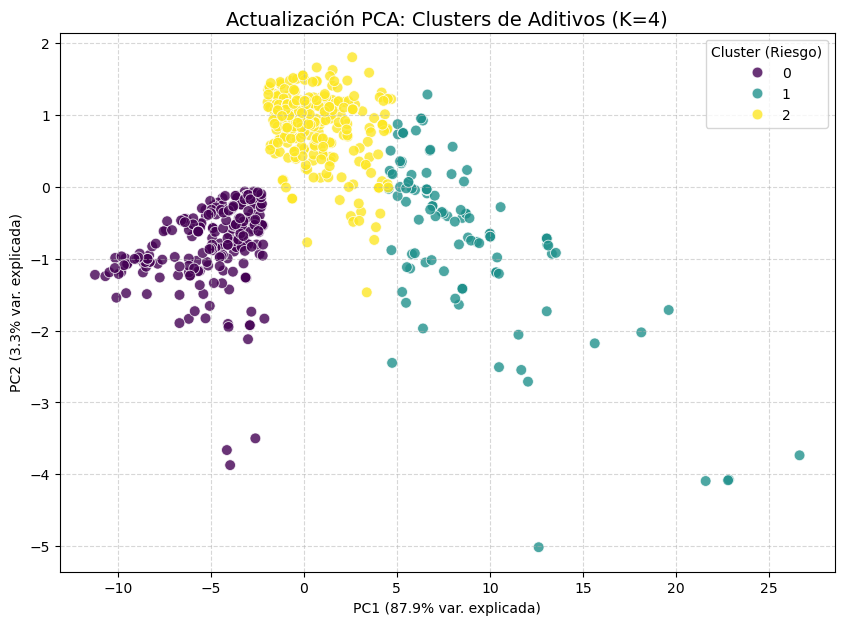

--- Distribución de Aditivos por Cluster ---
cluster
0    258
1    122
2    307
Name: count, dtype: int64


In [5]:
# 1. Preparar datos
features = df_pubmed.columns.drop(['id_original', 'nombre_referencia', 'codigo_e', 'id'])
X = df_pubmed[features]
# Aplicar logaritmo y escalado estándar (el método que dio la mejor distribución)
X_log = np.log1p(X)
X_scaled = StandardScaler().fit_transform(X_log)

# 2. Ejecutar K-Means con K=4
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_pubmed['cluster'] = kmeans.fit_predict(X_scaled)

# 3. Actualización de PCA: Visualización de Clusters en 2D
pca = PCA(n_components=2)
pca_results = pca.fit_transform(X_scaled)
df_pubmed['PCA1'] = pca_results[:, 0]
df_pubmed['PCA2'] = pca_results[:, 1]

# Generar el gráfico de dispersión actualizado
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PCA1', y='PCA2', hue='cluster', data=df_pubmed, palette='viridis', s=60, alpha=0.8)
plt.title('Actualización PCA: Clusters de Aditivos (K=4)', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var. explicada)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var. explicada)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Cluster (Riesgo)')
plt.savefig('../outputs/plots/aditives/pca_actualizado_clusters.png')
plt.show()


# Imprimir distribución para verificar equilibrio
print("--- Distribución de Aditivos por Cluster ---")
print(df_pubmed['cluster'].value_counts().sort_index())

In [ ]:


# Seleccionar columnas numéricas
features = df_pubmed.columns.drop(['id_original', 'nombre_referencia', 'PCA1', 'PCA2', 'id', 'codigo_e'])
X = df_pubmed[features]

# Preprocesamiento (igual que en los pasos anteriores para mantener consistencia)
X_log = np.log1p(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# Ejecutar PCA
pca = PCA(n_components=2) # Analizamos los 5 primeros para ver la estructura
pca.fit(X_scaled)

# Obtener las cargas (loadings)
# Las cargas indican cuánto contribuye cada variable original al componente principal
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(2)],
    index=features
)

# Mostrar las dimensiones más importantes para cada componente (Cargas > 0.2 o < -0.2)
print("--- Dimensiones con mayor peso en cada Componente Principal ---")
for col in loadings.columns:
    print(f"\n{col}:")
    top_features = loadings[col].sort_values(ascending=False)
    # Filtramos las que tienen un impacto significativo
    significant = top_features[abs(top_features) > 0.1]
    for feat, val in significant.items():
        print(f"  - {feat}: {val:.3f}")

--- Dimensiones con mayor peso en cada Componente Principal ---

PC1:
  - estudios_mecanisticos: 0.189
  - carcinogenesis: 0.189
  - inflamacion_pro: 0.189
  - estudios_in_vivo: 0.188
  - citoproteccion_salud: 0.188
  - neurotoxicidad: 0.188
  - bioacumulacion_persistencia: 0.188
  - actividad_antimicrobiana: 0.188
  - epigenetica: 0.187
  - toxicidad_genetica: 0.187
  - toxicidad_metabolica: 0.187
  - barrera_hematoencefalica: 0.186
  - estres_oxidativo: 0.186
  - alergia_inmune: 0.185
  - nefrotoxicidad: 0.185
  - autoinmunidad: 0.185
  - nanoparticulas: 0.185
  - interacciones: 0.185
  - barrera_intestinal: 0.184
  - antioxidante_tecnico: 0.184
  - disrupcion_endocrina: 0.183
  - microbiota_dysbiosis: 0.183
  - evidencia_humana: 0.180
  - hepatotoxicidad: 0.180
  - cardiotoxicidad: 0.179
  - total_docs: 0.179
  - valor_prebiotico: 0.177
  - toxicidad_emulsionantes: 0.172
  - toxicidad_conservadores: 0.137
  - toxicidad_edulcorantes: 0.134

PC2:
  - cluster: 0.676
  - total_docs: 0.2

FUSIONAMOS DATASETS

In [9]:

df_tax = pd.read_csv('../data/taxonomia_final_aditivos.csv')

df_alimentos = pd.read_csv('../data/dataset_800k_aditivos.csv')
# 2. Crear el diccionario de mapeo {nombre_columna: clase_riesgo}
# Usamos la columna 'id' de tu taxonomía para que coincida exactamente con el nombre de la columna dummy
mapping_riesgo = dict(zip(df_tax['id'].astype(str), df_tax['cluster']))

# 3. Inicializar las columnas de carga a cero en el dataset de alimentos
for i in range(4):
    df_alimentos[f'carga_clase_{i}'] = 0

# 4. Vincular por nombre de columna
print("Iniciando vinculación directa por nombre de columna...")
columnas_vinculadas = 0

for col_name in df_alimentos.columns:
    # Si el nombre de la columna en el dataset existe como ID en la taxonomía
    if col_name in mapping_riesgo:
        clase = mapping_riesgo[col_name]
        # Sumamos los dummies (1s y 0s) a la carga de su clase de riesgo
        df_alimentos[f'carga_clase_{clase}'] += df_alimentos[col_name].fillna(0)
        columnas_vinculadas += 1

# 5. Resultado final
print(f"✅ Se han vinculado {columnas_vinculadas} aditivos correctamente.")
print("\n--- SUMATORIO FINAL DE CARGAS ---")
print(df_alimentos[['carga_clase_0', 'carga_clase_1', 'carga_clase_2']].sum())

Iniciando vinculación directa por nombre de columna...
✅ Se han vinculado 572 aditivos correctamente.

--- SUMATORIO FINAL DE CARGAS ---
carga_clase_0     287478
carga_clase_1     586687
carga_clase_2    1048069
dtype: int64


### 5. Exportación y Trazabilidad
El proceso finaliza con la creación de una **Taxonomía Simplificada**, vinculando el resultado del cluster con el `codigo_e` y el `id` original, asegurando que los hallazgos sean aplicables a los productos reales de la base de datos de alimentos.

In [10]:
# 1. Definimos el mapeo de Nutri-Score a números
nutriscore_map = {'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5}

# 2. Seleccionamos las columnas definitivas (ajustado a 3 clusters de aditivos)
columnas_para_exportar = [ 
    'nutriscore_grade', 
    'nova_group', 
    'carga_clase_0', 
    'carga_clase_1', 
    'carga_clase_2'
]

# 3. Creamos el DataFrame final y limpiamos nulos básicos para evitar errores en la conversión
df_final_export = df_alimentos[columnas_para_exportar].copy().dropna()

# 4. Conversión de Nutri-Score (Letra -> Número)
df_final_export['nutriscore_grade'] = df_final_export['nutriscore_grade'].str.lower().map(nutriscore_map)

# 5. Aseguramos que NOVA y NutriScore sean enteros (int)
df_final_export['nova_group'] = df_final_export['nova_group'].astype(int)
df_final_export['nutriscore_grade'] = df_final_export['nutriscore_grade'].astype(int)

# 6. Exportación a CSV
df_final_export.to_csv('../data/dataset_alimentos_quimica_nutricion.csv', index=False)

print("✅ Archivo exportado con Nutri-Score numérico: 'dataset_alimentos_quimica_nutricion.csv'")
print(f"Dimensiones: {df_final_export.shape[0]} filas y {df_final_export.shape[1]} columnas.")
print("\nEjemplo de los primeros datos:")
print(df_final_export.head())

✅ Archivo exportado con Nutri-Score numérico: 'dataset_alimentos_quimica_nutricion.csv'
Dimensiones: 836199 filas y 5 columnas.

Ejemplo de los primeros datos:
   nutriscore_grade  nova_group  carga_clase_0  carga_clase_1  carga_clase_2
0                 2           1              0              0              0
1                 2           2              0              0              0
2                 5           4              1              0              4
3                 4           4              1              0              5
4                 5           3              0              0              0


In [43]:
df_final_export.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 836199 entries, 0 to 836198
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   nutriscore_grade  836199 non-null  int64
 1   nova_group        836199 non-null  int64
 2   carga_clase_0     836199 non-null  int64
 3   carga_clase_1     836199 non-null  int64
 4   carga_clase_2     836199 non-null  int64
dtypes: int64(5)
memory usage: 31.9 MB
